# 03 - Direction A: smarter retrieval and *relative* gates (no LLM)

**Idea.** Instead of one absolute score cut (notebook 01 showed it fails), (a) clean the customer message before searching
(`A_clean`: remove greetings, sign-offs, urgency filler, duplicate sentences), and (b) decide answer/refuse from the **shape of
the score list** rather than from one raw number:

| gate | "answer iff ..." |
|---|---|
| `top1` | the best rerank score is at least *t* (the current kind of gate) |
| `margin` | top-1 minus top-2 is at least *t* (the winner stands out) |
| `z` | top-1 is at least *t* standard deviations above the mean of the top 20 |
| `agree_overlap` | lexical and dense top-10 share at least *t*/10 passages (the two searches agree) |
| `agree_top1` | the final top-1 passage is in the top-10 of *t* of the 2 searches (0, 1 or 2) |

**Label.** A query is ANSWERABLE when its judged pool contains at least one grade-2 passage ("directly answers"). Each gate's
threshold is swept over every observed value and we report the best F1 for the *answer* decision (plus precision, recall, false-answer and
false-refusal rates). Best-F1 thresholds are tuned on the same 89 queries, so we also report a 5-fold cross-validated F1 (threshold chosen on 4/5, scored on 1/5): treat the
in-sample F1 as optimistic.

| | |
|---|---|
| **Required caches** | `cache/runs/R3_current.json`, `A_clean.json`, `R0_lex.json`, `R1_dense.json` (`uv run python -m experiments.run_variants`) |
| **Needed for real labels** | `cache/judgments.json` (`uv run python -m experiments.build_pools` then `uv run --env-file .env python -m experiments.llm.judge`). Without it the gate sweeps run on a **provisional** label (ANS answerable, OOD/ADJ unanswerable) and say so. |

In [1]:
import sys, pathlib, math, warnings
warnings.filterwarnings("ignore")
_here = pathlib.Path.cwd().resolve()
REPO = next(p for p in [_here, *_here.parents] if (p / "experiments" / "lab").is_dir())
sys.path[:0] = [str(REPO), str(REPO / "experiments")]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lab import notebook_utils as nu

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})
print("cache directory:", nu.cache_dir())

cache directory: /home/user/cato-networks/experiments/cache


In [2]:
RUNS = nu.load_runs(["R3_current", "A_clean", "R0_lex", "R1_dense"])
HAVE_RUNS = all(n in RUNS for n in ("R3_current", "A_clean", "R0_lex", "R1_dense"))
nu.need(HAVE_RUNS, "runs R3_current, A_clean, R0_lex, R1_dense", nu.CMD_RUN_VARIANTS)
Q = nu.load_queries()
J = nu.load_judgments()
HAVE_J = J is not None
QR = nu.qrels_from(J)
labels = nu.gold_labels(Q, J)
should = labels["label"].dropna().astype(bool)
print(nu.label_banner(labels))
GATES = ["top1", "margin", "z", "agree_overlap", "agree_top1"]
if HAVE_RUNS:
    FEATS = {n: nu.gate_features(RUNS[n], RUNS["R0_lex"], RUNS["R1_dense"]) for n in ("R3_current", "A_clean")}
    for n, f in FEATS.items():
        f["set"] = Q["set"]

PROVISIONAL LABELS: 57 of 57 labelled queries use the query-set prior (ANS=answerable, OOD/ADJ=unanswerable; SCN/TKT unlabelled). Run the judge to get real labels: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


## 1. What the cleaning does (real queries)

`clean_query` is deterministic. The table lists the queries that it actually changed (`A_clean` searches the cleaned text,
`R3_current` the raw message), and how many of them end up with a different top-1 article.

In [3]:
if nu.need(HAVE_RUNS, "runs R3_current, A_clean", nu.CMD_RUN_VARIANTS):
    try:
        from lab.retrieve import clean_query
    except Exception as exc:
        clean_query = None; print("clean_query unavailable:", exc)
    rows = []
    for qid in Q.index:
        raw = Q.loc[qid, "text"]; cl = clean_query(raw) if clean_query else raw
        a, b = FEATS["R3_current"].loc[qid], FEATS["A_clean"].loc[qid]
        rows.append({"id": qid, "set": Q.loc[qid, "set"], "text changed": cl != " ".join(raw.split()), "top1 article changed": a["top1_slug"] != b["top1_slug"],
                     "score raw": a["top1"], "score clean": b["top1"], "raw (start)": raw[:70], "cleaned (start)": cl[:70]})
    chg = pd.DataFrame(rows).set_index("id")
    print(f"{int(chg['text changed'].sum())} of {len(chg)} queries were changed by cleaning; the top-1 article changed for {int(chg['top1 article changed'].sum())}")
    display(chg[chg["text changed"]].sort_values("top1 article changed", ascending=False).head(15))

14 of 89 queries were changed by cleaning; the top-1 article changed for 5


,set,text changed,top1 article changed,score raw,score clean,raw (start),cleaned (start)
id,,,,,,,
SC-02-vague-slow,SCN,True,True,-6.170,-0.665,Internet is really slow for us. Please fix. Thanks.,Internet is really slow for us.
SC-03-sla-credit,SCN,True,True,-4.548,-5.051,Per our contract we are owed a service credit for the 6-hour outage on,Per our contract we are owed a service credit for the 6-hour outage on
TCK-20264209,TKT,True,True,4.312,4.152,Demanding SLA credit for the Aug 21 outage. Per our contract we are ow,Demanding SLA credit for the Aug 21 outage. Per our contract we are ow
TCK-20264214,TKT,True,True,-3.638,-2.105,Internet is slow. Internet is really slow for us. Please fix. Thanks.,Internet is slow. Internet is really slow for us.
TCK-20264238,TKT,True,True,-1.413,-2.335,Invoice charged twice this month. Our August invoice was charged twice,Invoice charged twice this month. Our August invoice was charged twice
SC-04-mfa-social-engineering,SCN,True,False,-9.164,-9.120,"This is Mark, assistant to our CEO at Pinnacle Health. He lost his pho","This is Mark, assistant to our CEO at Pinnacle Health. He lost his pho"
SC-07-multisite-outage-tier-claim,SCN,True,False,-4.535,-4.580,Both our German stores dropped within 5 minutes of each other. This lo,Both our German stores dropped within 5 minutes of each other. This lo
SC-09-no-kb-coverage,SCN,True,False,4.241,4.427,"Does Cato support IPv6-only branch sites, and what's on the roadmap fo","Does Cato support IPv6-only branch sites, and what's on the roadmap fo"
SC-12-socket-offline-after-upgrade,SCN,True,False,-2.816,-2.586,Our Denver Clinic Socket started its scheduled upgrade last night and,Our Denver Clinic Socket started its scheduled upgrade last night and


## 2. Retrieval quality: R3_current vs A_clean

In [4]:
if nu.need(HAVE_RUNS and HAVE_J, "judgments.json (+ runs)", nu.CMD_POOLS + " ; " + nu.CMD_JUDGE):
    PQ = {n: nu.per_query_metrics(RUNS[n], QR) for n in ("R3_current", "A_clean")}
    rows = []
    for n, m in PQ.items():
        rows.append({"run": n, **m.mean().to_dict()})
    cmp_ = pd.DataFrame(rows).set_index("run")
    diffs = []
    for metric in ("hit@1", "hit@5", "mrr", "ndcg@5"):
        x, y = PQ["A_clean"][metric], PQ["R3_current"][metric]
        ok = x.notna() & y.notna()
        d = nu.bootstrap_diff(nu.mean_stat(x[ok].to_numpy()), nu.mean_stat(y[ok].to_numpy()), int(ok.sum()))
        diffs.append({"metric": metric, "A_clean - R3": d["diff"], "CI low": d["lo"], "CI high": d["hi"], "zero inside CI": d["lo"] <= 0 <= d["hi"]})
    display(cmp_)
    display(pd.DataFrame(diffs).set_index("metric"))

SKIPPED - missing cache: judgments.json (+ runs)
  Run step first: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge


## 3. The gates: distributions of the numbers they look at

Each panel is one gate value for `R3_current`, split by gold label (blue answerable, red unanswerable). The more the two
clouds are separated along the axis, the better that gate can work.

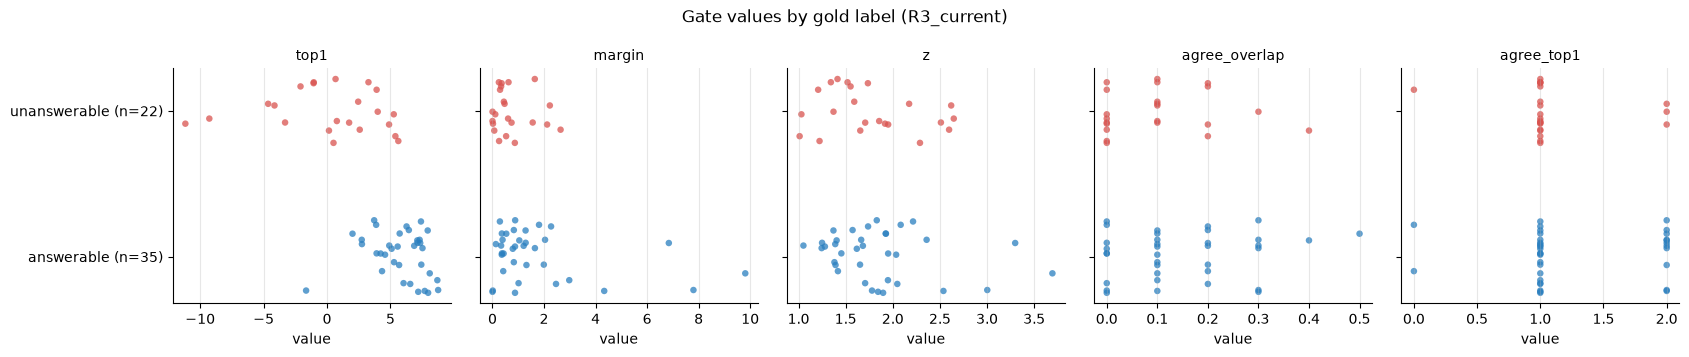

In [5]:
if nu.need(HAVE_RUNS, "runs", nu.CMD_RUN_VARIANTS):
    f = FEATS["R3_current"].copy()
    f["label"] = [nu.label_name(labels["label"].get(i)) for i in f.index]
    fig, axes = plt.subplots(1, len(GATES), figsize=(3.4 * len(GATES), 3.6), sharey=True)
    for ax, g in zip(axes, GATES):
        nu.strip(ax, {n: f.loc[f["label"] == n, g] for n in ("answerable", "unanswerable") if (f["label"] == n).any()}, nu.LABEL_COLORS)
        ax.set_title(g, fontsize=10); ax.set_xlabel("value")
    plt.suptitle("Gate values by gold label (R3_current)"); plt.tight_layout(); plt.show()

## 4. Threshold sweeps for each gate

For every gate and each of the two runs: best threshold by answer-F1, with precision, recall, false-answer rate (unanswerable
queries still answered), false-refusal rate (answerable queries refused), cross-validated F1 and AUC (0.5 = no separation).

In [6]:
STUDY, SWEEPS = {}, {}
if nu.need(HAVE_RUNS and len(should) > 0, "runs and labels", nu.CMD_RUN_VARIANTS):
    for n in ("R3_current", "A_clean"):
        STUDY[n], SWEEPS[n] = nu.gate_study(FEATS[n], should, GATES)
    both = pd.concat(STUDY, names=["run"])
    display(both)

best threshold    F1  precision  recall  false-answer rate  false-refusal rate  answered  F1 (5-fold CV)   AUC
run        gate                                                                                                                         
R3_current top1                    2.736 0.880      0.825   0.943              0.318               0.057        40           0.795 0.899
           margin                  0.287 0.780      0.681   0.914              0.682               0.086        47           0.750 0.681
           z                       1.245 0.782      0.654   0.971              0.818               0.029        52           0.764 0.536
           agree_overlap           0.000 0.761      0.614   1.000              1.000               0.000        57           0.761 0.611
           agree_top1              0.000 0.761      0.614   1.000              1.000               0.000        57           0.761 0.580
A_clean    top1                    2.736 0.880      0.825   0.943              0.318               0.057        40           0.795 0.899
           margin                  0.287 0.780      0.681   0.914              0.682               0.086        47           0.750 0.681
           z                       1.245 0.782      0.654   0.971              0.818               0.029        52           0.764 0.536
           agree_overlap           0.000 0.761      0.614   1.000              1.000               0.000        57           0.761 0.611
           agree_top1              0.000 0.761      0.614   1.000              1.000               0.000        57           0.761 0.580

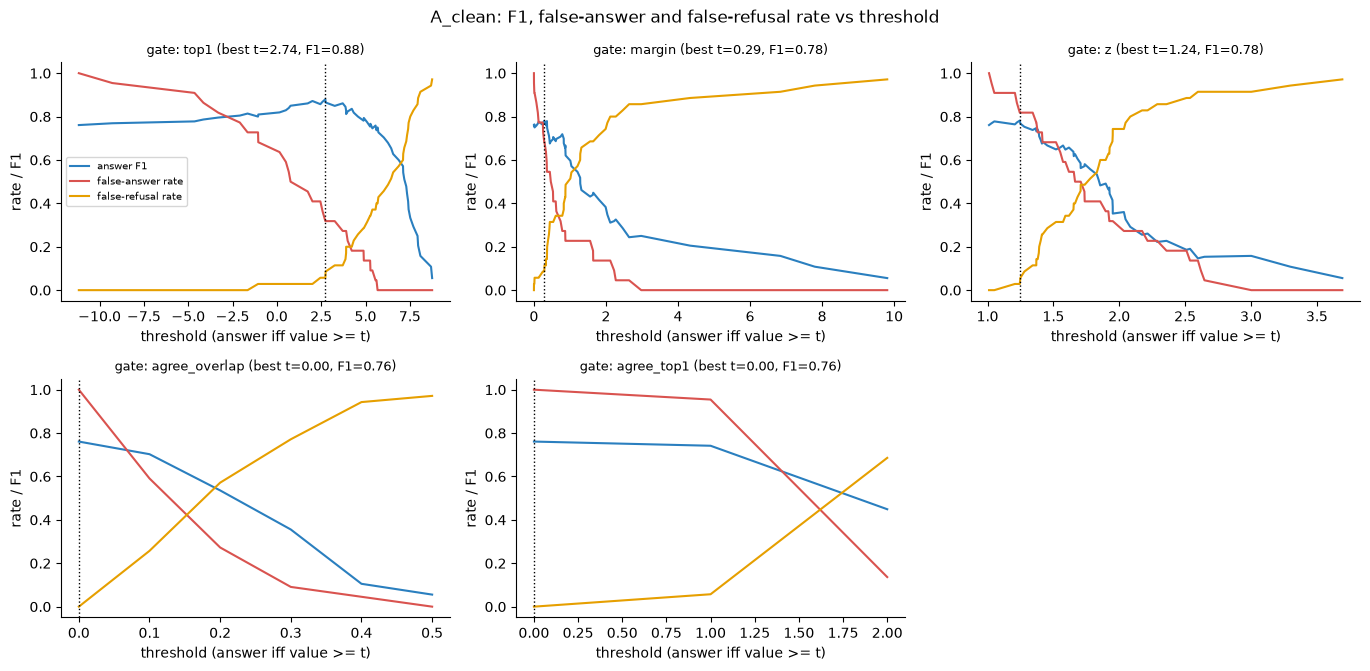

In [7]:
if nu.need(bool(SWEEPS), "gate sweeps", nu.CMD_RUN_VARIANTS):
    fig = nu.plot_sweeps(SWEEPS["A_clean"], "A_clean: F1, false-answer and false-refusal rate vs threshold"); plt.show()

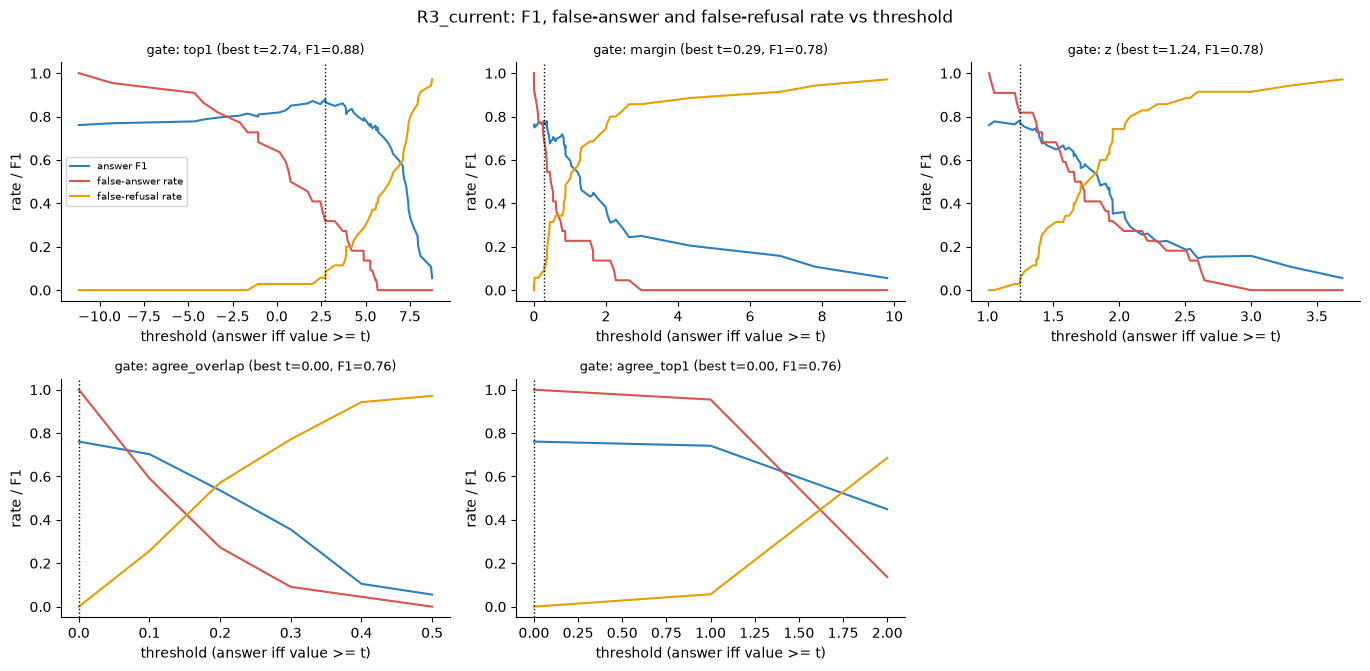

In [8]:
if nu.need(bool(SWEEPS), "gate sweeps", nu.CMD_RUN_VARIANTS):
    fig = nu.plot_sweeps(SWEEPS["R3_current"], "R3_current: F1, false-answer and false-refusal rate vs threshold"); plt.show()

## 5. Do relative gates beat the absolute cut?

The `top1` row is the absolute cut (what plan 04 tried). If a relative gate's F1 is not clearly above it (and above its own CV
F1), it is not a real improvement: with 89 queries a few points is noise (see the bootstrap CI in the result table).

# RESULT TABLE - Direction A (best configuration per gate)

Sorted by F1. `run` is the retrieval (raw message or cleaned), `gate` the decision rule. CI = bootstrap 95% interval of the F1
at the chosen threshold (resampling queries, threshold fixed).

In [9]:
if nu.need(bool(STUDY), "gate study", nu.CMD_RUN_VARIANTS):
    rows = []
    for n, st in STUDY.items():
        for g, r in st.iterrows():
            did = (FEATS[n].loc[should.index, g].astype(float).fillna(-math.inf) >= r["best threshold"]).tolist()
            ci = nu.bootstrap_ci(nu.f1_stat(should.tolist(), did), len(should))
            rows.append({"run": n, "gate": g, "threshold": r["best threshold"], "answer F1": r["F1"], "F1 95% CI": f"[{ci[1]:.2f}, {ci[2]:.2f}]",
                         "F1 (5-fold CV)": r["F1 (5-fold CV)"], "false-answer rate": r["false-answer rate"], "false-refusal rate": r["false-refusal rate"], "AUC": r["AUC"]})
    RESULT_A = pd.DataFrame(rows).sort_values("answer F1", ascending=False).reset_index(drop=True)
    display(RESULT_A)
    top, absolute = RESULT_A.iloc[0], RESULT_A[RESULT_A["gate"] == "top1"].iloc[0]
    print(nu.label_banner(labels))
    print(f"BEST A CONFIG: run={top['run']}, gate={top['gate']}, threshold {top['threshold']:.3f}: F1 {top['answer F1']:.3f} "
          f"(CV {top['F1 (5-fold CV)']:.3f}), false-answer {top['false-answer rate']:.0%}, false-refusal {top['false-refusal rate']:.0%}.")
    print(f"Absolute cut on its own ({absolute['run']}): F1 {absolute['answer F1']:.3f}. Gain of best A config over the absolute cut: {100 * (top['answer F1'] - absolute['answer F1']):+.1f} F1 points.")

,run,gate,threshold,answer F1,F1 95% CI,F1 (5-fold CV),false-answer rate,false-refusal rate,AUC
0,R3_current,top1,2.736,0.880,"[0.79, 0.95]",0.795,0.318,0.057,0.899
1,A_clean,top1,2.736,0.880,"[0.79, 0.95]",0.795,0.318,0.057,0.899
2,A_clean,z,1.245,0.782,"[0.67, 0.87]",0.764,0.818,0.029,0.536
3,R3_current,z,1.245,0.782,"[0.67, 0.87]",0.764,0.818,0.029,0.536
4,R3_current,margin,0.287,0.780,"[0.68, 0.87]",0.750,0.682,0.086,0.681
5,A_clean,margin,0.287,0.780,"[0.68, 0.87]",0.750,0.682,0.086,0.681
6,R3_current,agree_top1,0.000,0.761,"[0.66, 0.85]",0.761,1.000,0.000,0.580
7,R3_current,agree_overlap,0.000,0.761,"[0.66, 0.85]",0.761,1.000,0.000,0.611
8,A_clean,agree_overlap,0.000,0.761,"[0.66, 0.85]",0.761,1.000,0.000,0.611
9,A_clean,agree_top1,0.000,0.761,"[0.66, 0.85]",0.761,1.000,0.000,0.580


PROVISIONAL LABELS: 57 of 57 labelled queries use the query-set prior (ANS=answerable, OOD/ADJ=unanswerable; SCN/TKT unlabelled). Run the judge to get real labels: uv run python -m experiments.build_pools ; uv run --env-file .env python -m experiments.llm.judge
BEST A CONFIG: run=R3_current, gate=top1, threshold 2.736: F1 0.880 (CV 0.795), false-answer 32%, false-refusal 6%.
Absolute cut on its own (R3_current): F1 0.880. Gain of best A config over the absolute cut: +0.0 F1 points.
